In [ ]:
# Install Prophet
!pip install prophet pandas matplotlib scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

In [ ]:
# Load the dataset
df = pd.read_csv('pipeline_disk_metrics.csv', on_bad_lines='skip')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# Resample to 10-minute intervals to smooth noise
ts = df['util_pct'].resample('10T').mean().interpolate()

# Reset index and rename columns to satisfy Prophet's strict 'ds' and 'y' naming convention
prophet_df = ts.reset_index()
prophet_df.columns = ['ds', 'y']

print("Data ready for Prophet. Total rows:", len(prophet_df))
print(prophet_df.head())

Data ready for Prophet. Total rows: 278
                   ds          y
0 2026-06-03 00:30:00  18.355844
1 2026-06-03 00:40:00  18.573684
2 2026-06-03 00:50:00  19.039640
3 2026-06-03 01:00:00  19.400000
4 2026-06-03 01:10:00  20.600000


In [ ]:
# Reserve the last 6 hours (36 steps of 10 mins) for testing
forecast_horizon = 36
train = prophet_df.iloc[:-forecast_horizon]
test = prophet_df.iloc[-forecast_horizon:]

# Initialize Prophet Model
# changepoint_prior_scale controls how flexible the trend is to sudden drops.
# Increasing it slightly (default is 0.05) helps the model adapt to your cliff-drops.
model = Prophet(
    changepoint_prior_scale=0.1,
    daily_seasonality=True,
    yearly_seasonality=False,
    weekly_seasonality=False
)

# Fit on training data
model.fit(train)

# Predict the validation set
future_val = model.make_future_dataframe(periods=forecast_horizon, freq='10T')
forecast_val = model.predict(future_val)

# Extract just the predictions for the test window
predictions = forecast_val['yhat'].iloc[-forecast_horizon:]

# Calculate Loss Metrics
rmse = np.sqrt(mean_squared_error(test['y'], predictions))
mae = mean_absolute_error(test['y'], predictions)

print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE:  {mae:.4f}")

Validation RMSE: 0.8290
Validation MAE:  0.7492


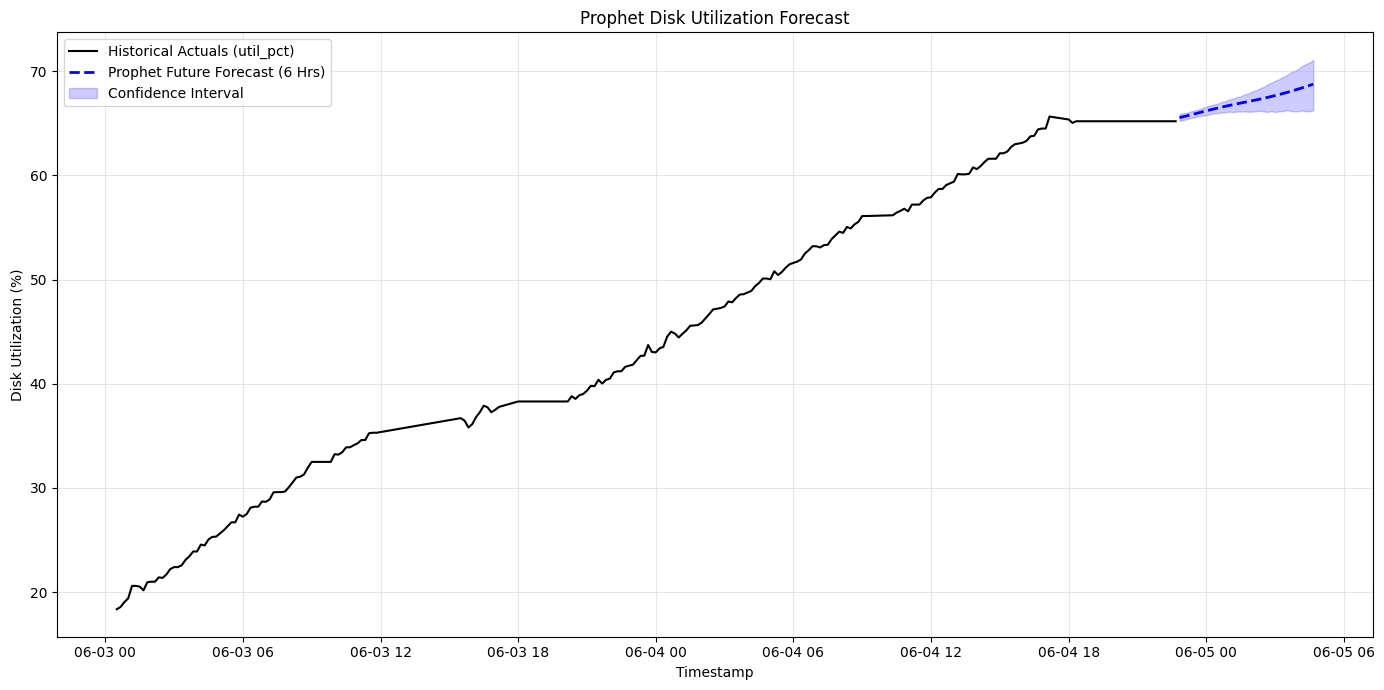


--- Upcoming 6-Hour Forecast Data ---
                     ds       yhat  yhat_lower  yhat_upper
304 2026-06-05 03:10:00  67.756638   66.147958   69.223186
305 2026-06-05 03:20:00  67.854122   66.160983   69.439949
306 2026-06-05 03:30:00  67.955558   66.267460   69.600543
307 2026-06-05 03:40:00  68.060869   66.191989   69.874329
308 2026-06-05 03:50:00  68.169873   66.157164   70.008054
309 2026-06-05 04:00:00  68.282290   66.160376   70.191540
310 2026-06-05 04:10:00  68.397754   66.219771   70.486238
311 2026-06-05 04:20:00  68.515826   66.164794   70.688053
312 2026-06-05 04:30:00  68.636009   66.153592   70.823070
313 2026-06-05 04:40:00  68.757764   66.241545   71.097048


In [ ]:
# Retrain a fresh model on ALL available data for the true future forecast
final_model = Prophet(
    changepoint_prior_scale=0.1,
    daily_seasonality=True,
    yearly_seasonality=False,
    weekly_seasonality=False
)
final_model.fit(prophet_df)

# Create a dataframe stretching 6 hours (36 steps) into the future
future_forecast_df = final_model.make_future_dataframe(periods=forecast_horizon, freq='10T')

# Generate the final forecast
forecast_future = final_model.predict(future_forecast_df)

# --- PLOTTING ---
plt.figure(figsize=(14, 7))

# Plot historical data
plt.plot(prophet_df['ds'], prophet_df['y'], label='Historical Actuals (util_pct)', color='black', linewidth=1.5)

# Plot future forecast
future_dates = forecast_future['ds'].iloc[-forecast_horizon:]
future_preds = forecast_future['yhat'].iloc[-forecast_horizon:]
future_lower = forecast_future['yhat_lower'].iloc[-forecast_horizon:]
future_upper = forecast_future['yhat_upper'].iloc[-forecast_horizon:]

plt.plot(future_dates, future_preds, label='Prophet Future Forecast (6 Hrs)', color='blue', linestyle='--', linewidth=2)

# Shade the uncertainty / confidence interval
plt.fill_between(future_dates, future_lower, future_upper, color='blue', alpha=0.2, label='Confidence Interval')

plt.title('Prophet Disk Utilization Forecast')
plt.xlabel('Timestamp')
plt.ylabel('Disk Utilization (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the final predicted values
print("\n--- Upcoming 6-Hour Forecast Data ---")
print(forecast_future[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

- Prophet is highly effective for forecasting OpenSearch disk utilization because it natively accommodates the sudden, discrete step-changes typical of Index State Management (ISM) log rotations and cleanups.

- The custom monitoring CLI tool captures these metrics with extreme precision through direct Linux system calls and a local poller, resulting in rigid,
sharp space reclamation drops that cause standard sequential models like ARIMA to flatline.

- By utilizing flexible changepoint detection and explicit daily seasonality, Prophet successfully navigates these abrupt disk-clearing events while accurately projecting the underlying log ingestion trend.


Generating Component Plots...


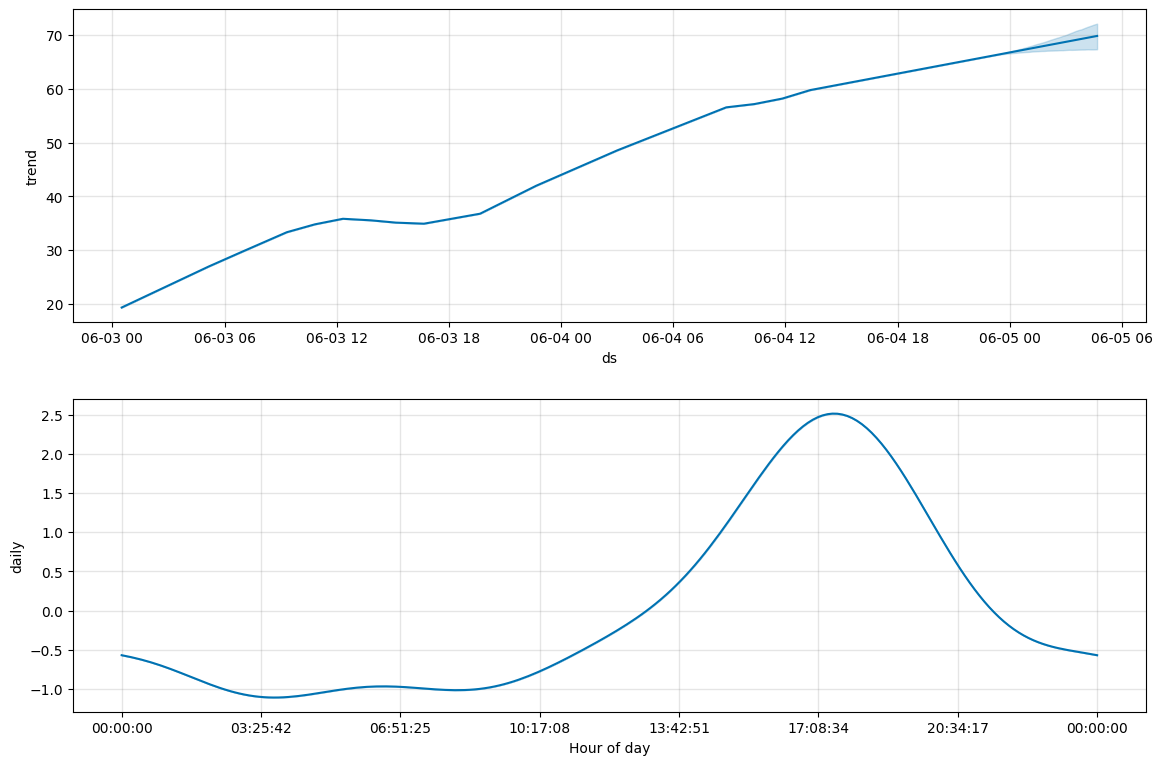

In [ ]:
# --- Plot Components (Trend & Seasonality) ---
print("Generating Component Plots...")
# plot_components shows the isolated trend line and the daily seasonal pattern
fig_components = final_model.plot_components(forecast_future)

# Increase figure size for better readability in Colab
fig_components.set_size_inches(12, 8)
plt.show()

Generating Changepoints Plot...


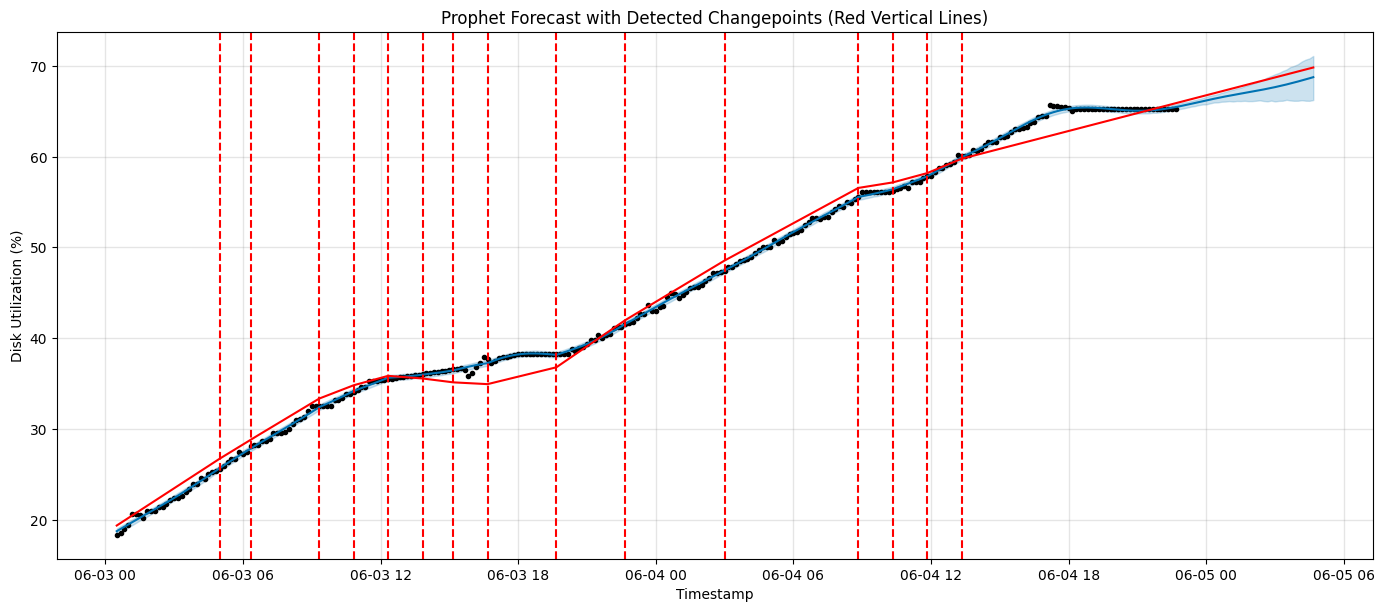

In [ ]:
from prophet.plot import add_changepoints_to_plot

# --- Plot Changepoints ---
print("Generating Changepoints Plot...")
fig_changepoints = final_model.plot(forecast_future, figsize=(14, 6))

# Overlay the changepoints (red dotted lines) and the trendline (solid red line)
ax = fig_changepoints.gca()
add_changepoints_to_plot(ax, final_model, forecast_future)

plt.title('Prophet Forecast with Detected Changepoints (Red Vertical Lines)')
plt.xlabel('Timestamp')
plt.ylabel('Disk Utilization (%)')
plt.show()

INFO:prophet:Making 5 forecasts with cutoffs between 2026-06-04 00:40:00 and 2026-06-04 16:40:00


Running Cross-Validation... (This may take a minute)


  0%|          | 0/5 [00:00<?, ?it/s]


--- Averaged Cross-Validation Metrics ---
          horizon      rmse       mae      mape
0 0 days 00:40:00  0.626490  0.456762  0.007772
1 0 days 00:50:00  0.703822  0.536088  0.009063
2 0 days 01:00:00  0.720502  0.561117  0.009433
3 0 days 01:10:00  0.707277  0.579409  0.009790
4 0 days 01:20:00  0.705499  0.583074  0.009864

Generating Cross-Validation Metric Plot...


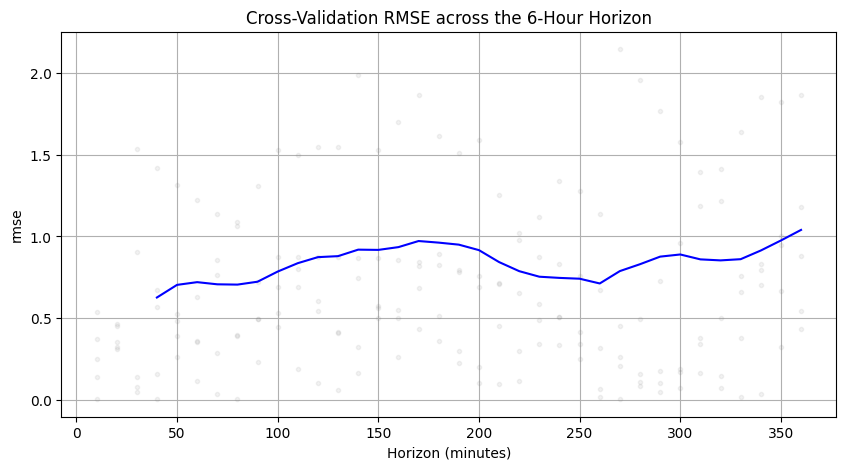

In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import logging

# Suppress cmdstanpy logging to keep Colab output clean during CV
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

print("Running Cross-Validation... (This may take a minute)")

# Simulate historical forecasts:
# Train on first 24 hours, then make a 6-hour forecast every 4 hours.
df_cv = cross_validation(
    final_model,
    initial='24 hours',
    period='4 hours',
    horizon='6 hours'
)

# Calculate aggregate metrics across all simulated forecasts
df_metrics = performance_metrics(df_cv)
print("\n--- Averaged Cross-Validation Metrics ---")
print(df_metrics[['horizon', 'rmse', 'mae', 'mape']].head())

# --- Plot Cross Validation RMSE over the horizon ---
print("\nGenerating Cross-Validation Metric Plot...")
fig_cv = plot_cross_validation_metric(df_cv, metric='rmse')
fig_cv.set_size_inches(10, 5)
plt.title('Cross-Validation RMSE across the 6-Hour Horizon')
plt.show()

# Hyperparameter tuning and increasing accuracy

In [ ]:
# Install required libraries
!pip install prophet pandas matplotlib scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import logging
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
from prophet.plot import add_changepoints_to_plot
import warnings

# Suppress benign warnings and noisy Prophet logs to keep the Colab output clean
warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

In [ ]:
# Load the dataset safely
df = pd.read_csv('pipeline_disk_metrics.csv', on_bad_lines='skip')

# Enforce datetime and set index
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# Resample to 10-minute intervals and interpolate any resulting missing values
ts = df['util_pct'].resample('10T').mean().interpolate()

# Format strictly for Prophet ('ds' and 'y')
prophet_df = ts.reset_index()
prophet_df.columns = ['ds', 'y']

print(f"Data successfully preprocessed. Total valid rows: {len(prophet_df)}")

Data successfully preprocessed. Total valid rows: 278


In [ ]:
print("Starting Hyperparameter Grid Search... This will take a few minutes.")

# Define the grid of parameters to test
# - changepoint_prior_scale: How aggressively the model reacts to sudden drops (Higher = more flexible)
# - seasonality_prior_scale: How heavily it relies on the daily 24-hour cycle
# - seasonality_mode: Does the daily cycle scale with overall data size (multiplicative) or stay static (additive)?
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.1, 1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative']
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []  # Store the RMSEs for each param combination

# Iterate through every combination
for params in all_params:
    # Initialize model with the current parameter set
    m = Prophet(**params, daily_seasonality=True, yearly_seasonality=False, weekly_seasonality=False)
    m.fit(prophet_df)

    # Run cross-validation: Train on first 24h, predict 6h, advance by 4h, repeat.
    # Note: If your dataset is smaller than ~40 hours, decrease 'initial' to '12 hours'
    df_cv = cross_validation(m, initial='24 hours', period='4 hours', horizon='6 hours', parallel="processes")

    # Calculate performance metrics
    df_p = performance_metrics(df_cv, rolling_window=1)
    # Extract the Root Mean Squared Error
    rmses.append(df_p['rmse'].values[0])

# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses
best_params = all_params[np.argmin(rmses)]

print("\n--- Grid Search Complete ---")
print(f"Best Parameters Found: {best_params}")
print(f"Lowest Cross-Validation RMSE Achieved: {min(rmses):.4f}")

Starting Hyperparameter Grid Search... This will take a few minutes.


INFO:prophet:Making 5 forecasts with cutoffs between 2026-06-04 00:40:00 and 2026-06-04 16:40:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x79c1e5839e50>
INFO:prophet:Making 5 forecasts with cutoffs between 2026-06-04 00:40:00 and 2026-06-04 16:40:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x79c1e5750620>
INFO:prophet:Making 5 forecasts with cutoffs between 2026-06-04 00:40:00 and 2026-06-04 16:40:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x79c1dc906450>
INFO:prophet:Making 5 forecasts with cutoffs between 2026-06-04 00:40:00 and 2026-06-04 16:40:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x79c1e525acf0>
INFO:prophet:Making 5 forecasts with cutoffs between 2026-06-04 00:40:00 and 2026-06-04 16:40:00
INFO:prophet:Applying in parallel with <concurrent.futures.proc


--- Grid Search Complete ---
Best Parameters Found: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}
Lowest Cross-Validation RMSE Achieved: 0.8390


Optimized Validation RMSE: 0.8290
Optimized Validation MAE:  0.7492


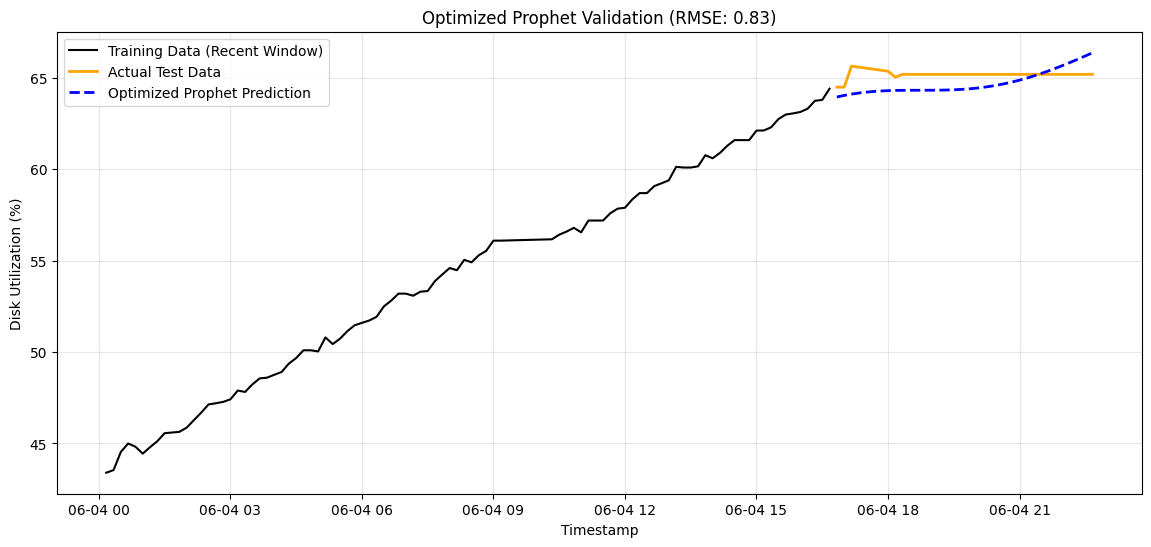

In [ ]:
# Reserve the last 6 hours (36 steps of 10 mins) for testing
forecast_horizon = 36
train = prophet_df.iloc[:-forecast_horizon]
test = prophet_df.iloc[-forecast_horizon:]

# Initialize Model with the BEST parameters found in Grid Search
opt_model = Prophet(**best_params, daily_seasonality=True, yearly_seasonality=False, weekly_seasonality=False)
opt_model.fit(train)

# Predict the validation set
future_val = opt_model.make_future_dataframe(periods=forecast_horizon, freq='10T')
forecast_val = opt_model.predict(future_val)
predictions = forecast_val['yhat'].iloc[-forecast_horizon:]

# Calculate strict Loss Metrics
opt_rmse = np.sqrt(mean_squared_error(test['y'], predictions))
opt_mae = mean_absolute_error(test['y'], predictions)

print(f"Optimized Validation RMSE: {opt_rmse:.4f}")
print(f"Optimized Validation MAE:  {opt_mae:.4f}")

# Plot Validation
plt.figure(figsize=(14, 6))
plt.plot(train['ds'].iloc[-100:], train['y'].iloc[-100:], label='Training Data (Recent Window)', color='black')
plt.plot(test['ds'], test['y'], label='Actual Test Data', color='orange', linewidth=2)
plt.plot(test['ds'], predictions, label='Optimized Prophet Prediction', color='blue', linestyle='--', linewidth=2)
plt.title(f'Optimized Prophet Validation (RMSE: {opt_rmse:.2f})')
plt.xlabel('Timestamp')
plt.ylabel('Disk Utilization (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

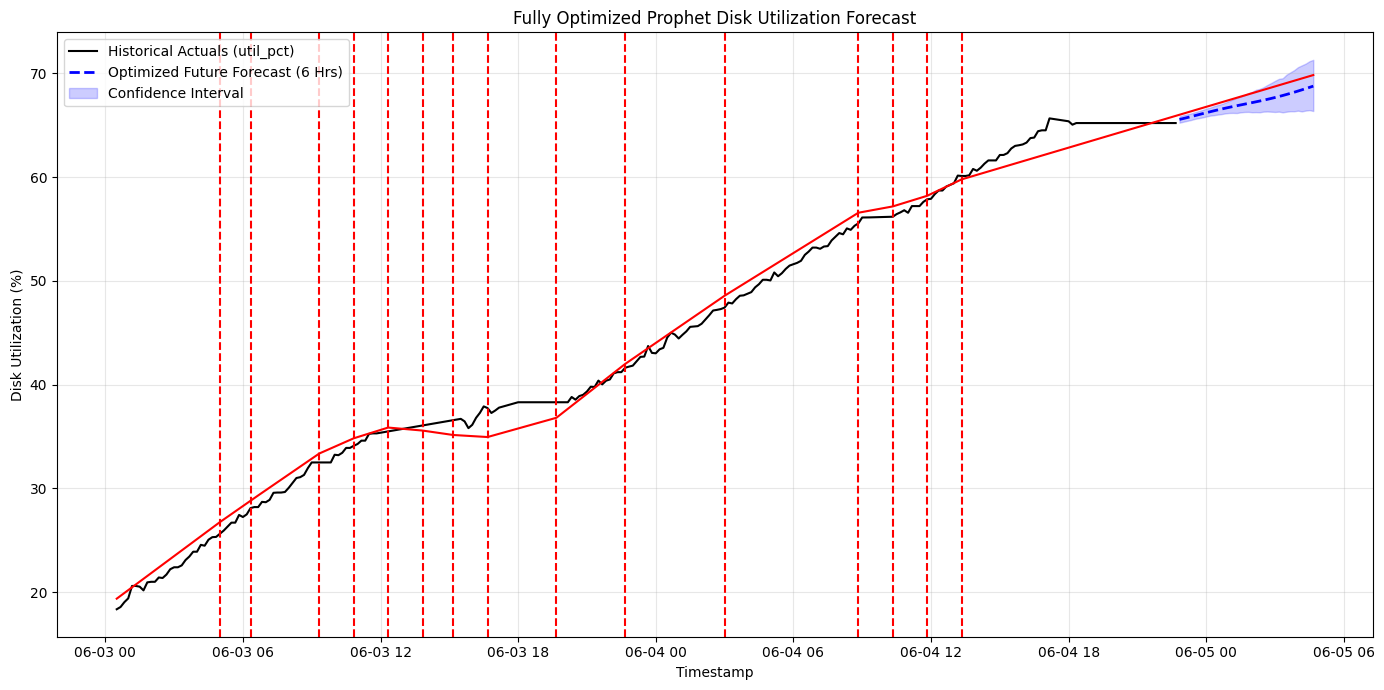

In [ ]:
# Train the ultimate model on ALL data
final_model = Prophet(**best_params, daily_seasonality=True, yearly_seasonality=False, weekly_seasonality=False)
final_model.fit(prophet_df)

# Create a dataframe stretching 6 hours into the future
future_forecast_df = final_model.make_future_dataframe(periods=forecast_horizon, freq='10T')
forecast_future = final_model.predict(future_forecast_df)

# --- PLOTTING ---
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(111)

# Plot historical actuals
ax.plot(prophet_df['ds'], prophet_df['y'], label='Historical Actuals (util_pct)', color='black', linewidth=1.5)

# Plot future forecast
future_dates = forecast_future['ds'].iloc[-forecast_horizon:]
future_preds = forecast_future['yhat'].iloc[-forecast_horizon:]
future_lower = forecast_future['yhat_lower'].iloc[-forecast_horizon:]
future_upper = forecast_future['yhat_upper'].iloc[-forecast_horizon:]

ax.plot(future_dates, future_preds, label='Optimized Future Forecast (6 Hrs)', color='blue', linestyle='--', linewidth=2)
ax.fill_between(future_dates, future_lower, future_upper, color='blue', alpha=0.2, label='Confidence Interval')

# Overlay the detected changepoints to prove it caught the ISM cleanups
add_changepoints_to_plot(ax, final_model, forecast_future)

plt.title('Fully Optimized Prophet Disk Utilization Forecast')
plt.xlabel('Timestamp')
plt.ylabel('Disk Utilization (%)')
# Moving legend to upper left to avoid covering the future forecast
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()